# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Utility Store Dataset](https://www.kaggle.com/datasets/mabubakrsiddiq/utility-store-sales-dataset-2026-1k-rows)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('utility_store_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Index,Item,Category,Original Price,Discount Percentage,Date
0,1,Ball Pen Pack,Stationery,1468.48,23,2026-04-21
1,2,Dishwashing Liquid,Cleaning,2917.65,35,2026-07-02
2,3,Tape Roll,Stationery,2467.63,39,2026-03-24
3,4,LED Bulb 12W,Electrical,3643.53,36,2026-06-20
4,5,Ball Pen Pack,Stationery,2869.89,36,2026-08-22


## last Five row

In [4]:
df.tail()

,Index,Item,Category,Original Price,Discount Percentage,Date
995,996,Tape Roll,Stationery,1933.36,17,2026-08-16
996,997,Extension Cord,Electrical,1853.90,39,2026-02-25
997,998,Extension Cord,Electrical,4920.43,27,2026-05-30
998,999,Extension Cord,Electrical,344.81,18,2026-05-10
999,1000,USB Cable,Electronics,4471.32,7,2026-07-17


## Shape of our dataset

In [5]:
df.shape

(1000, 6)

## List out all columns

In [6]:
df.columns

Index(['Index', 'Item', 'Category', 'Original Price', 'Discount Percentage',
       'Date'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Index                    int64
Item                    object
Category                object
Original Price         float64
Discount Percentage      int64
Date                    object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Index                1000 non-null   int64  
 1   Item                 1000 non-null   object 
 2   Category             1000 non-null   object 
 3   Original Price       1000 non-null   float64
 4   Discount Percentage  1000 non-null   int64  
 5   Date                 1000 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 47.0+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Index                  0
Item                   0
Category               0
Original Price         0
Discount Percentage    0
Date                   0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Index,Original Price,Discount Percentage
count,1000.000000,1000.000000,1000.000000
mean,500.500000,2546.202350,20.261000
std,288.819436,1400.056557,11.914564
min,1.000000,100.650000,0.000000
25%,250.750000,1372.747500,9.000000
50%,500.500000,2549.930000,20.000000
75%,750.250000,3742.580000,31.000000
max,1000.000000,4997.010000,40.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

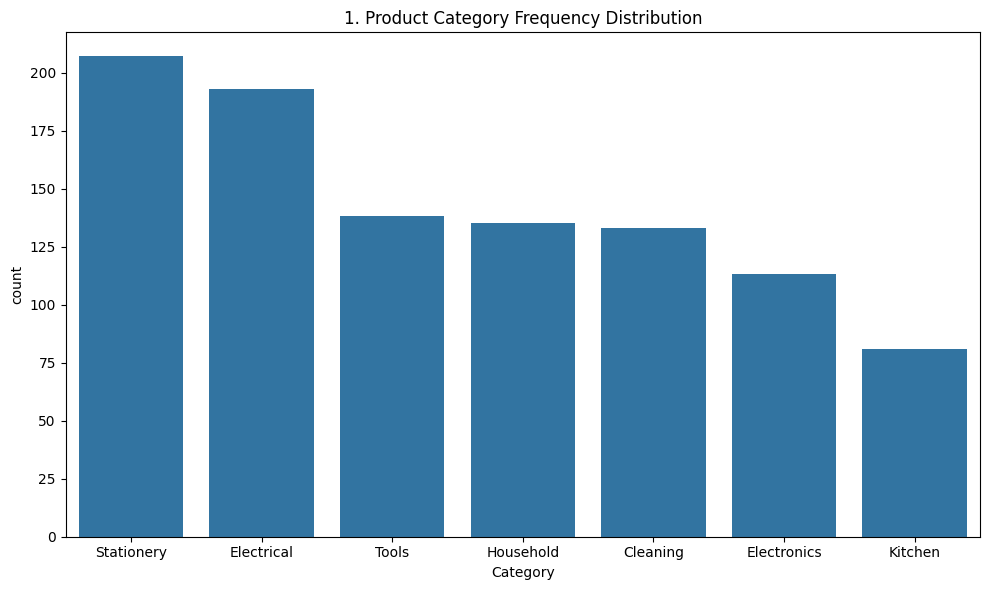

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Category', data=df, order=df['Category'].value_counts().index)
plt.title(f'{plot_no}. Product Category Frequency Distribution')
show_fig()
plot_no += 1

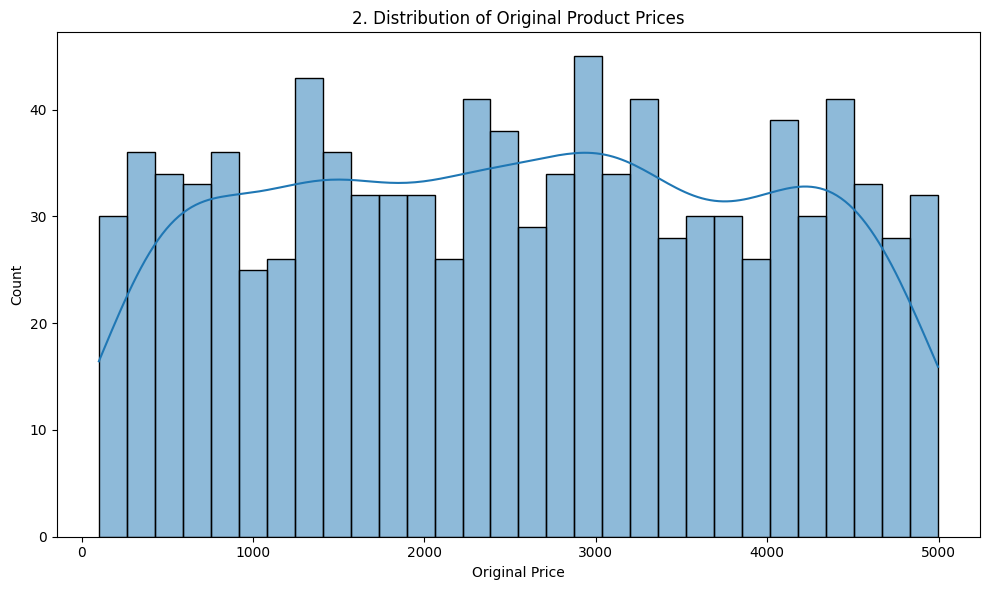

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Original Price'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Original Product Prices')
show_fig()
plot_no += 1

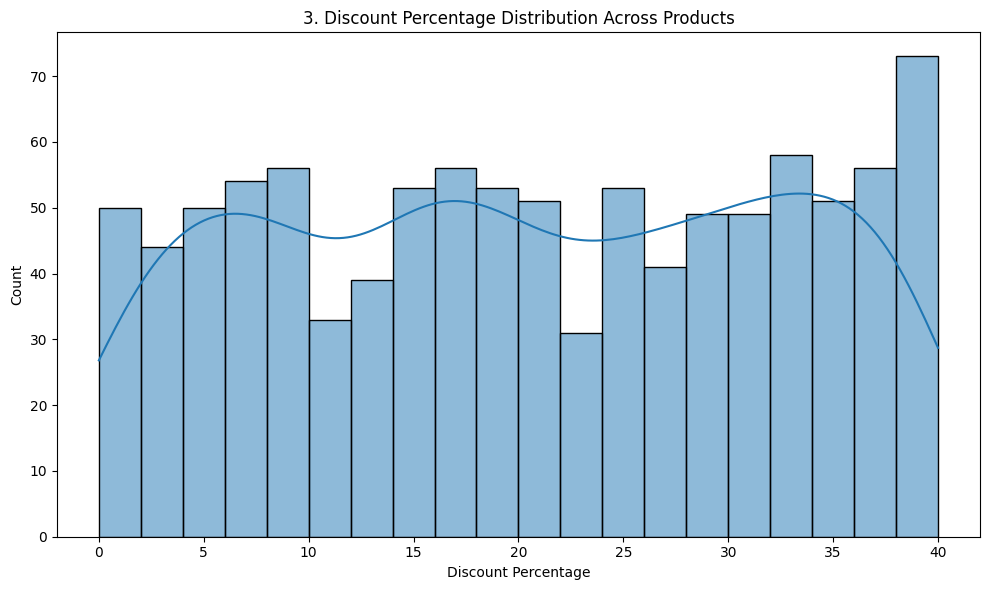

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Discount Percentage'], bins=20, kde=True)
plt.title(f'{plot_no}. Discount Percentage Distribution Across Products')
show_fig()
plot_no += 1

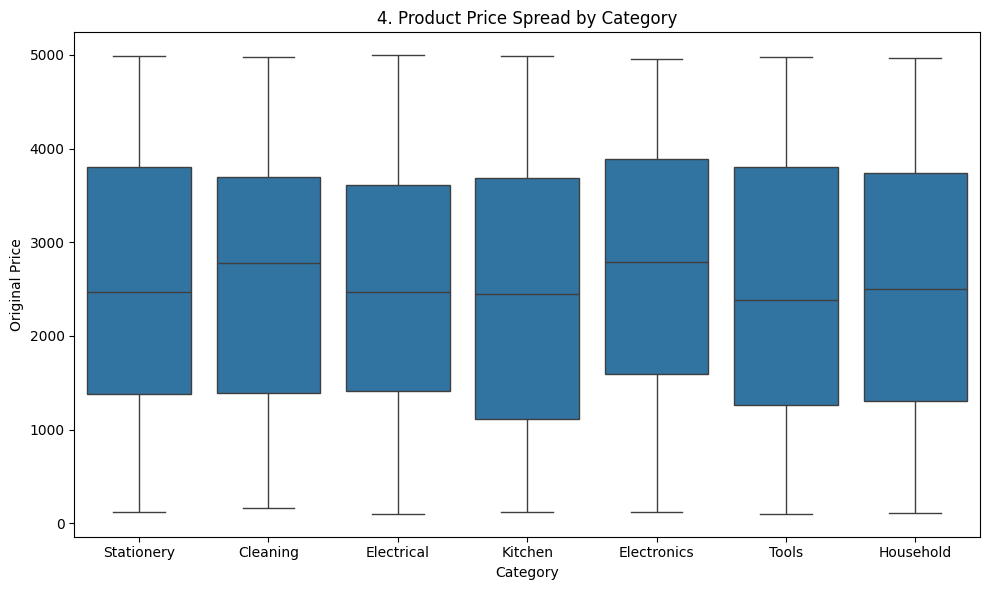

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Category', y='Original Price', data=df)
plt.title(f'{plot_no}. Product Price Spread by Category')
show_fig()
plot_no += 1

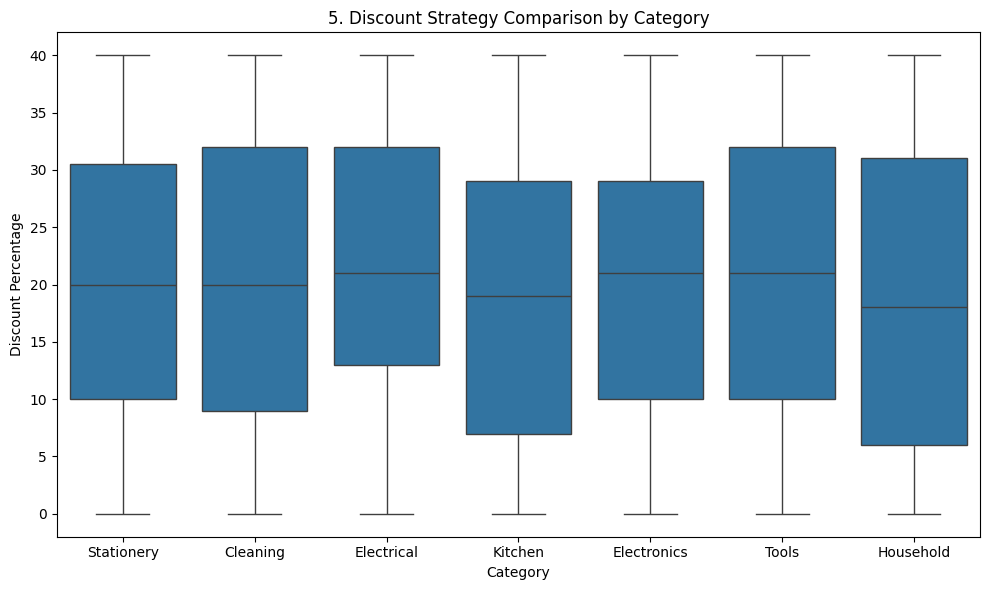

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Category', y='Discount Percentage', data=df)
plt.title(f'{plot_no}. Discount Strategy Comparison by Category')
show_fig()
plot_no += 1

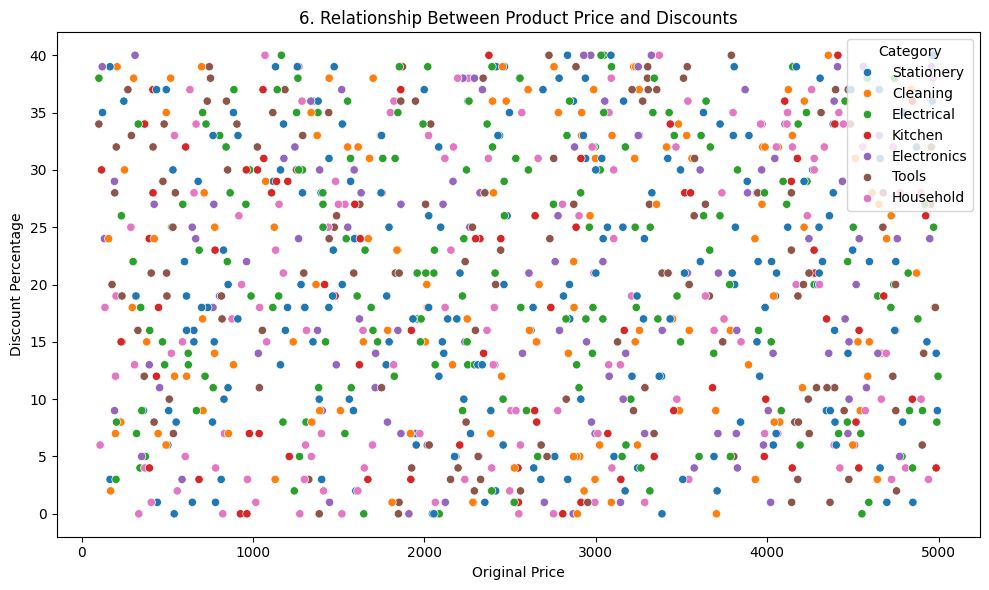

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='Original Price', y='Discount Percentage', hue='Category', data=df)
plt.title(f'{plot_no}. Relationship Between Product Price and Discounts')
show_fig()
plot_no += 1

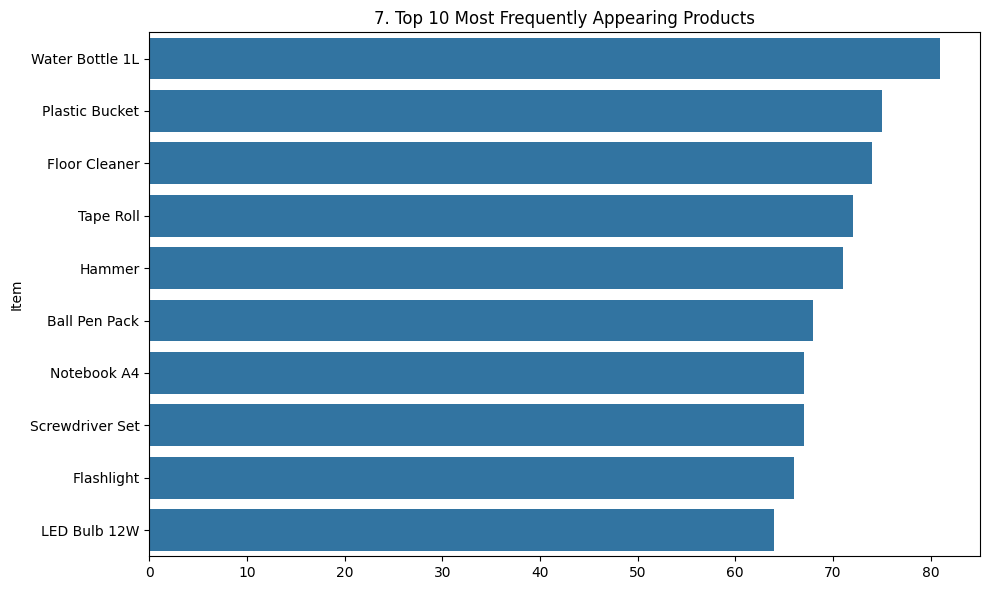

In [19]:
fig = plt.figure(figsize=(10,6))
top_items = df['Item'].value_counts().head(10)
sns.barplot(x=top_items.values, y=top_items.index)
plt.title(f'{plot_no}. Top 10 Most Frequently Appearing Products')
show_fig()
plot_no += 1

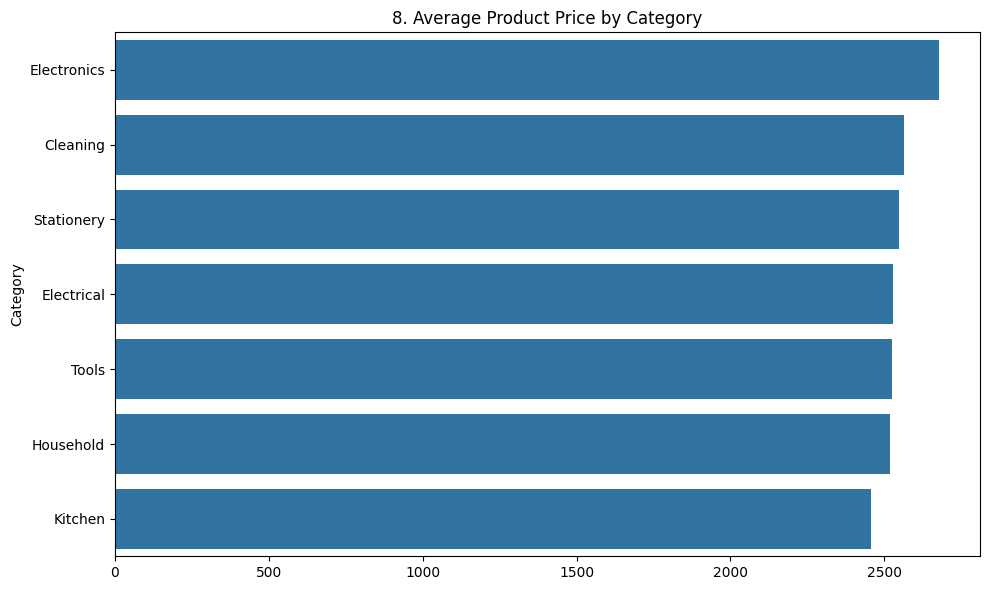

In [20]:
fig = plt.figure(figsize=(10,6))
avg_price = df.groupby('Category')['Original Price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.values, y=avg_price.index)
plt.title(f'{plot_no}. Average Product Price by Category')
show_fig()
plot_no += 1

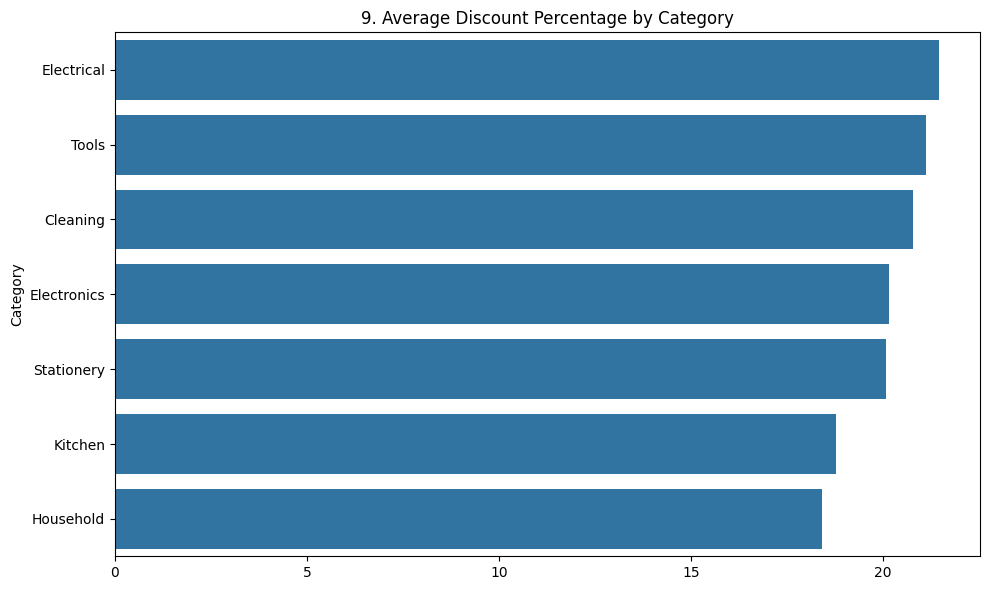

In [21]:
fig = plt.figure(figsize=(10,6))
avg_discount = df.groupby('Category')['Discount Percentage'].mean().sort_values(ascending=False)
sns.barplot(x=avg_discount.values, y=avg_discount.index)
plt.title(f'{plot_no}. Average Discount Percentage by Category')
show_fig()
plot_no += 1

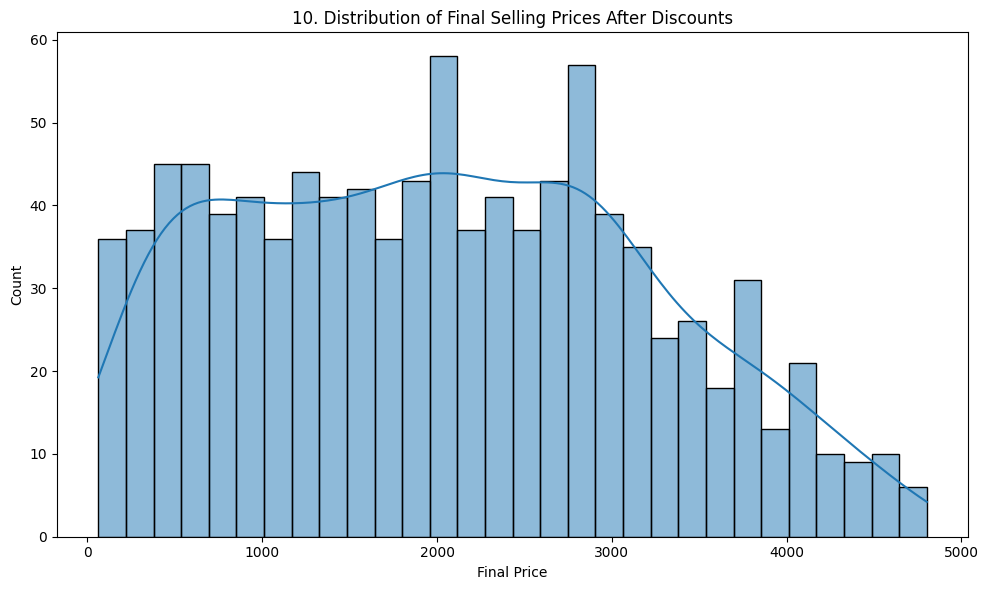

In [22]:
fig = plt.figure(figsize=(10,6))
df['Final Price'] = df['Original Price'] - (df['Original Price'] * df['Discount Percentage'] / 100)
sns.histplot(df['Final Price'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Final Selling Prices After Discounts')
show_fig()
plot_no += 1

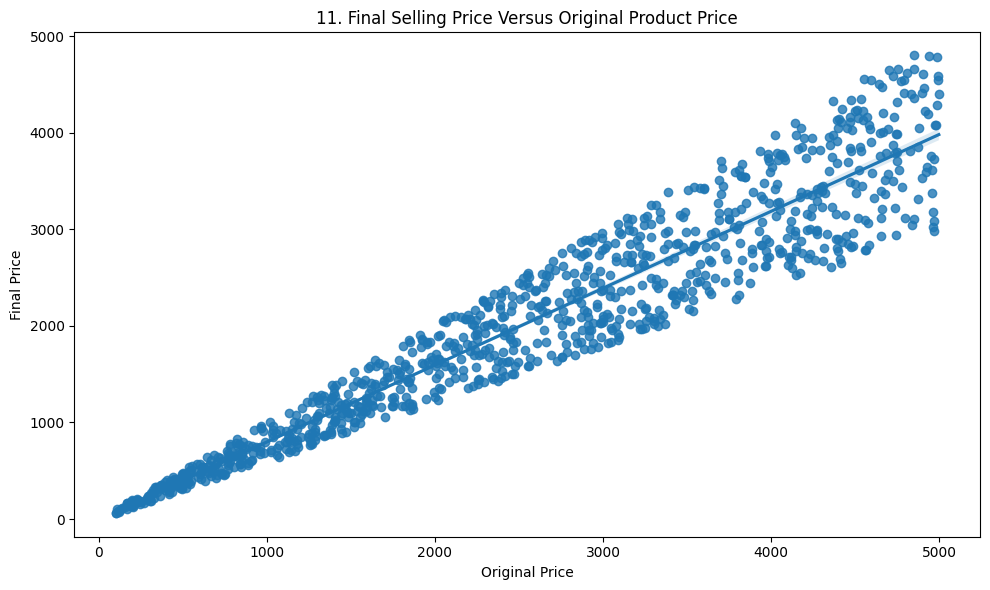

In [23]:
fig = plt.figure(figsize=(10,6))
sns.regplot(x='Original Price', y='Final Price', data=df)
plt.title(f'{plot_no}. Final Selling Price Versus Original Product Price')
show_fig()
plot_no += 1

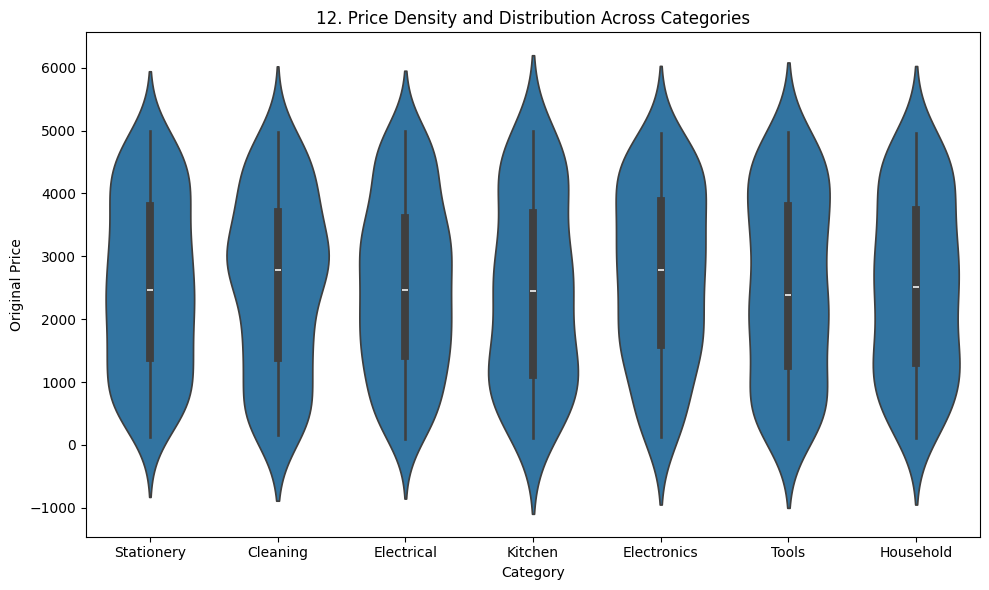

In [24]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Category', y='Original Price', data=df)
plt.title(f'{plot_no}. Price Density and Distribution Across Categories')
show_fig()
plot_no += 1

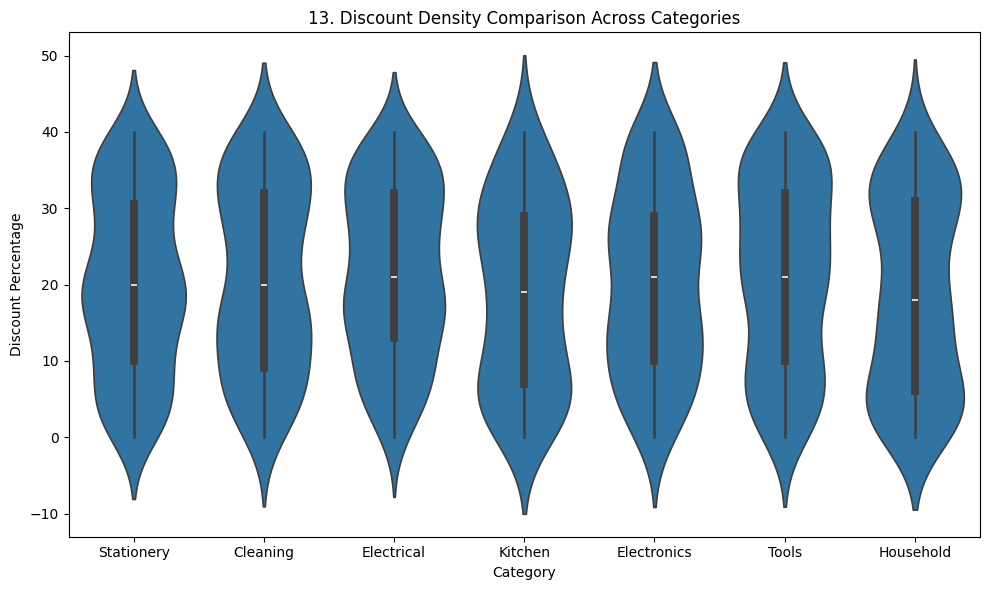

In [25]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Category', y='Discount Percentage', data=df)
plt.title(f'{plot_no}. Discount Density Comparison Across Categories')
show_fig()
plot_no += 1

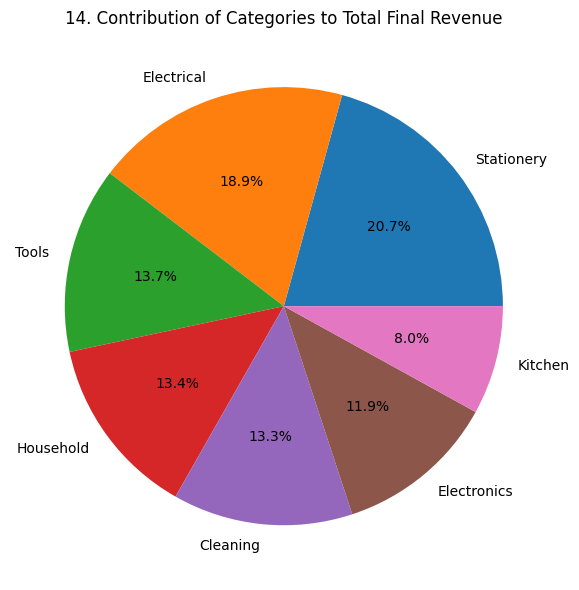

In [26]:
fig = plt.figure(figsize=(10,6))
category_final = df.groupby('Category')['Final Price'].sum().sort_values(ascending=False)
plt.pie(category_final.values, labels=category_final.index, autopct='%1.1f%%')
plt.title(f'{plot_no}. Contribution of Categories to Total Final Revenue')
show_fig()
plot_no += 1

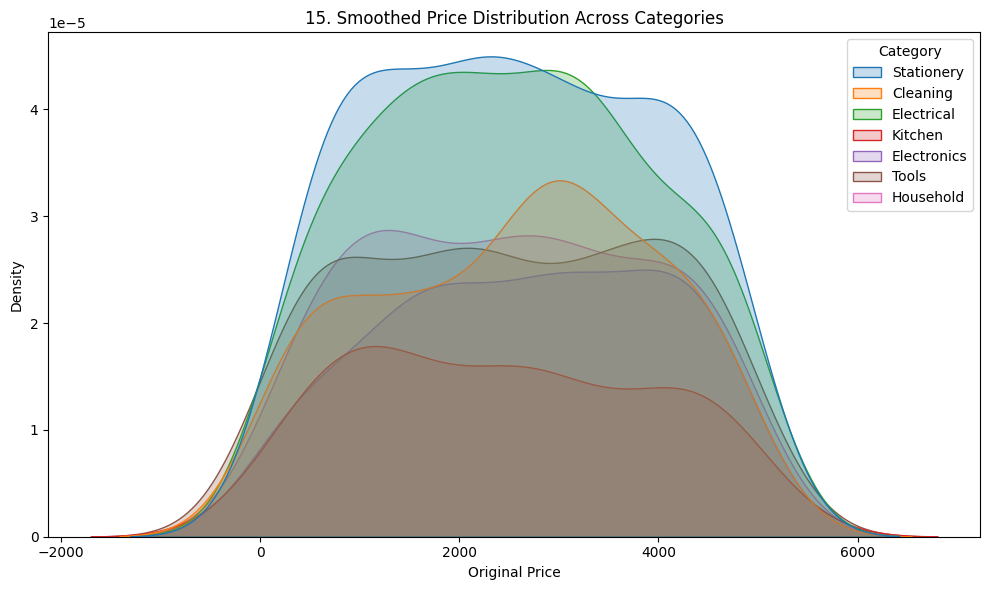

In [27]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Original Price', hue='Category', fill=True)
plt.title(f'{plot_no}. Smoothed Price Distribution Across Categories')
show_fig()
plot_no += 1

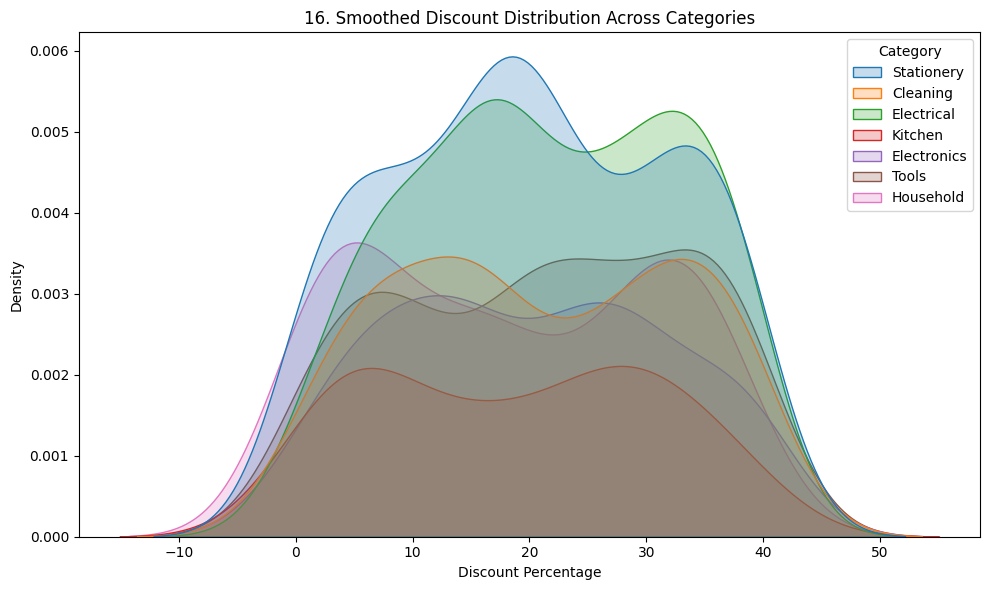

In [28]:
fig = plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Discount Percentage', hue='Category', fill=True)
plt.title(f'{plot_no}. Smoothed Discount Distribution Across Categories')
show_fig()
plot_no += 1

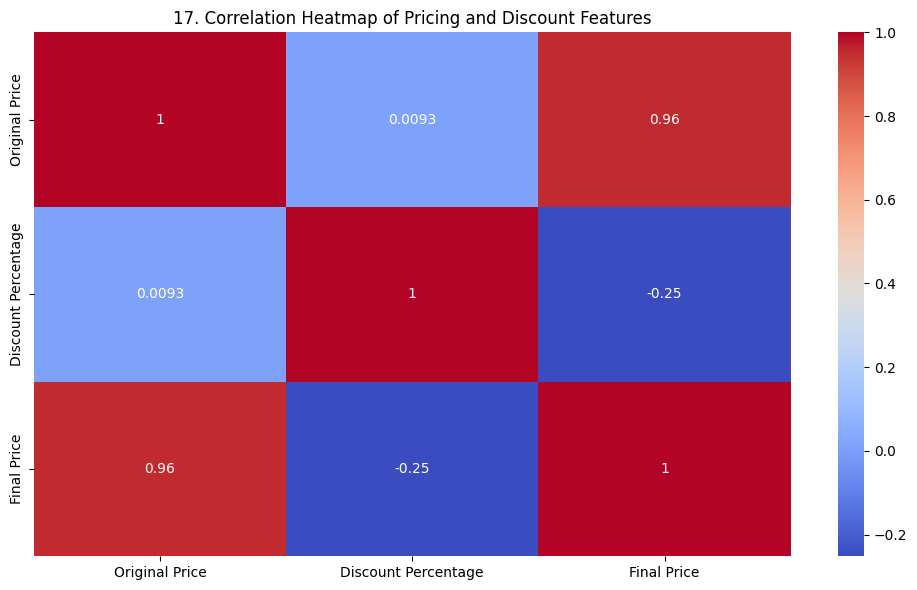

In [29]:
fig = plt.figure(figsize=(10,6))
corr = df[['Original Price', 'Discount Percentage', 'Final Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Pricing and Discount Features')
show_fig()
plot_no += 1

# Model Training

## create target column

In [30]:
df['Final Price'] = df['Original Price'] - (df['Original Price'] * df['Discount Percentage'] / 100)

## select features and target

In [31]:
X = df[['Item', 'Category', 'Original Price', 'Discount Percentage']]
y = df['Final Price']

## encode categorical columns

In [32]:
X = X.copy()
le_item = LabelEncoder()
le_category = LabelEncoder()

X['Item'] = le_item.fit_transform(X['Item'])
X['Category'] = le_category.fit_transform(X['Category'])

## split dataset

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## scale features

In [34]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train supervised model

In [35]:
model = SVR(kernel='rbf', C=100, gamma='scale')
model.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## predict values

In [36]:
y_pred = model.predict(X_test)

## print evaluation metrics

In [37]:
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))

R2 Score : 0.9860246284943085
MAE : 74.70800597033154


## actual vs predicted chart

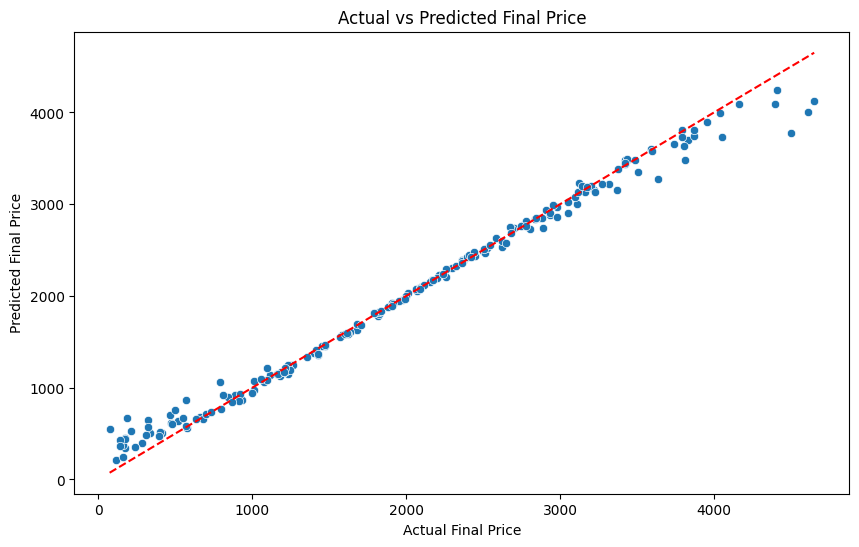

In [38]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Final Price')
plt.ylabel('Predicted Final Price')
plt.title('Actual vs Predicted Final Price')
plt.show()